# DINOv2 特征 + SVM/RF 全流程 Notebook

本 Notebook 仅保留以下能力：
1. 使用 DINOv2 默认预训练模型做特征提取
2. 训练 SVM / Logistic Regression / 小 MLP 分类器
3. 对未标注图片目录推理
4. 按可选数量进行结果可视化

In [3]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
from PIL import Image

import sys
sys.path.insert(0, "/home/tmpuser/YanLinkopingUni/Serier/serier_classifier")

from post_training.infer_with_svm_classifier import infer_with_svm_classifier

/home/tmpuser/miniconda3/envs/serier-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# 根据你的环境修改这三个路径
DATASET_ROOT = Path("/media/tmpuser/DATA/yan_serier/new_training_dataset/split")
UNLABELED_IMAGE_DIR = Path("/media/tmpuser/DATA/yan_serier/DNserier_test")
WORK_DIR = Path("/media/tmpuser/DATA/yan_serier/dinov2_logreg_model")

CLASSIFIER_TYPE = "logreg"  # 可选: 'svm' / 'logreg' / 'mlp'
COMPARE_METHODS = ["svm", "logreg", "mlp"]  # 可选：批量比较时使用

# 分别指定两类可视化数量（<=0 表示该类不显示）
COMICS_VIZ_SAMPLES = 8
NOCOMICS_VIZ_SAMPLES = 8

WORK_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR

PosixPath('/media/tmpuser/DATA/yan_serier/dinov2_logreg_model')

## 1) 训练分类器（train/val/test）

训练脚本会自动使用 DINOv2 默认预训练权重，不需要 checkpoint。

In [5]:
import sys
from post_training.train_svm_classifier import main as train_svm_main
from post_training.train_logreg_classifier import main as train_logreg_main
from post_training.train_mlp_classifier import main as train_mlp_main

train_output = WORK_DIR / f"{CLASSIFIER_TYPE}_classifier"
script_name = {"svm": "train_svm_classifier", "logreg": "train_logreg_classifier", "mlp": "train_mlp_classifier"}[CLASSIFIER_TYPE]
train_main = {"svm": train_svm_main, "logreg": train_logreg_main, "mlp": train_mlp_main}[CLASSIFIER_TYPE]

argv_backup = sys.argv
sys.argv = [
    script_name,
    "--dataset-root", str(DATASET_ROOT),
    "--output-dir", str(train_output),
    "--svm-c-grid", "0.1,1,10",
    "--svm-gamma-grid", "1e-4,1e-3,1e-2",
    "--mlp-hidden", "256",
]

try:
    train_main()
finally:
    sys.argv = argv_backup

classifier_path = train_output / f"{CLASSIFIER_TYPE}_classifier.pkl"
results_path = train_output / "results.json"
classifier_path, results_path

训练样本: 4485
验证样本: 961
测试样本: 963


/home/tmpuser/miniconda3/envs/serier-env/lib/python3.10/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


提取训练集特征...
训练集 TTA 特征提取: pass 1/3


提取特征: 100%|██████████| 141/141 [02:37<00:00,  1.12s/it]


训练集 TTA 特征提取: pass 2/3


...

提取特征: 100%|██████████| 31/31 [00:19<00:00,  1.57it/s]


提取测试集特征...


提取特征: 100%|██████████| 31/31 [00:19<00:00,  1.59it/s]


不平衡处理（过采样）: {'applied': True, 'minority_class': 1, 'majority_class': 0, 'added_samples': 4688, 'target_ratio': 1.0, 'before': {'nocomics': 5067, 'comics': 379}, 'after': {'nocomics': 5067, 'comics': 5067}}
训练拟合标签分布（处理前）: {'nocomics': 5067, 'comics': 379}
训练拟合标签分布（处理后）: {'nocomics': 5067, 'comics': 5067}
训练 Logistic Regression 分类器...
评估分类器...
训练完成!
分类器类型: LOGREG
Train Acc: 0.9875
Val   Acc: 0.9865
Test  Acc: 0.9823
结果保存至: /media/tmpuser/DATA/yan_serier/dinov2_logreg_model/logreg_classifier


(PosixPath('/media/tmpuser/DATA/yan_serier/dinov2_logreg_model/logreg_classifier/logreg_classifier.pkl'),
 PosixPath('/media/tmpuser/DATA/yan_serier/dinov2_logreg_model/logreg_classifier/results.json'))

In [6]:
results = json.loads(results_path.read_text(encoding="utf-8"))
{
    "classifier_type": results["classifier_type"],
    "train_accuracy": results["train_accuracy"],
    "val_accuracy": results["val_accuracy"],
    "test_accuracy": results["test_accuracy"],
}

{'classifier_type': 'logreg',
 'train_accuracy': 0.9875139353400223,
 'val_accuracy': 0.9864724245577523,
 'test_accuracy': 0.9823468328141225}

## 2) 推理未标注数据

In [7]:
infer_output = WORK_DIR / f"{CLASSIFIER_TYPE}_infer"
summary = infer_with_svm_classifier(
    image_dir=str(UNLABELED_IMAGE_DIR),
    classifier_path=str(classifier_path),
    output_dir=infer_output,
)
summary

提取特征: 100%|██████████| 387/387 [01:40<00:00,  3.86it/s]


{'total': 6192,
 'class_distribution': {0: 6058, 1: 134},
 'avg_confidence': 0.9677029161709498,
 'feature_strategy': 'cls_plus_patch_mean_concat',
 'feature_l2_normalized': True,
 'output_folders': {'nocomics': '/media/tmpuser/DATA/yan_serier/dinov2_logreg_model/logreg_infer/nocomics',
  'comics': '/media/tmpuser/DATA/yan_serier/dinov2_logreg_model/logreg_infer/comics'}}

## 3) 可选：按数量可视化推理结果

Total predictions: 6192
Predicted comics: 134
Predicted nocomics: 6058


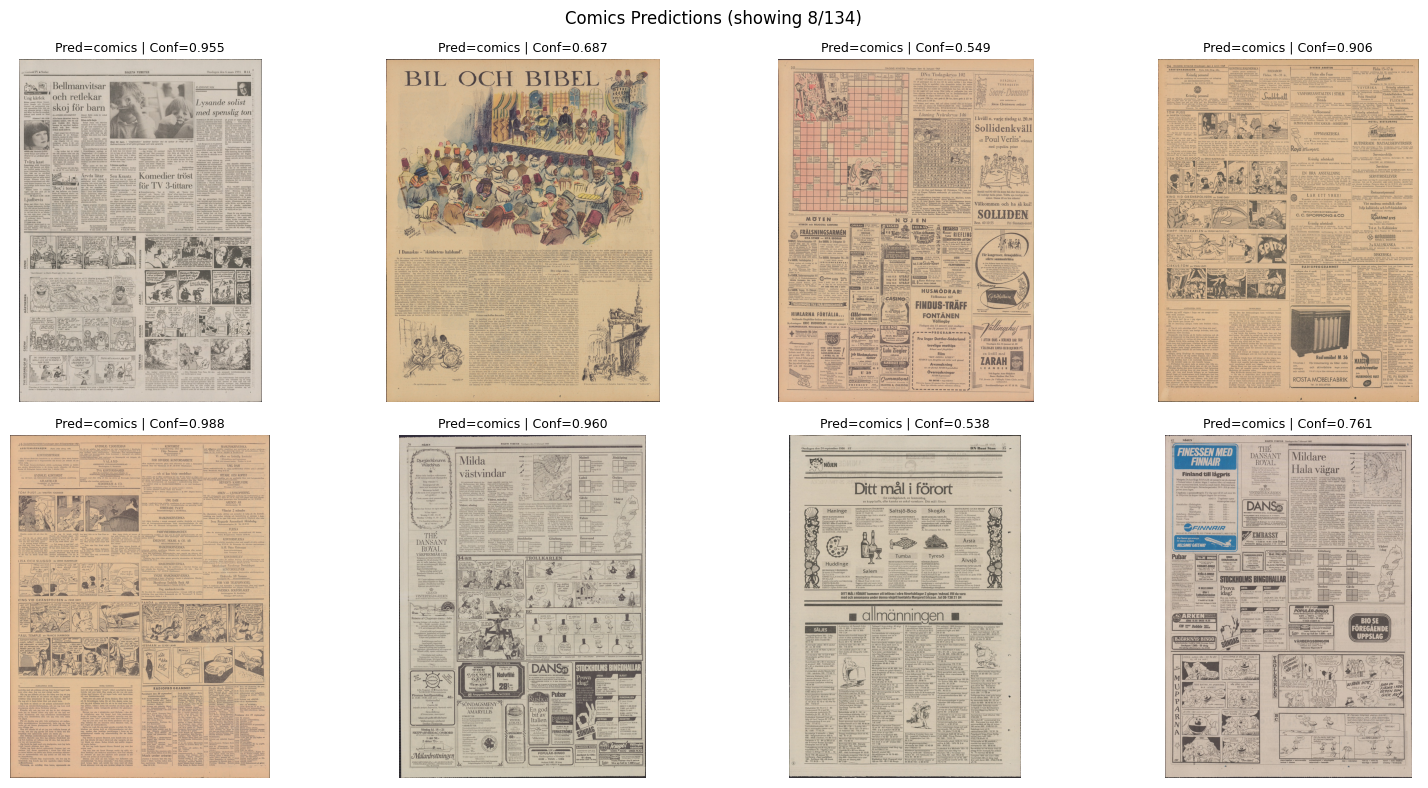

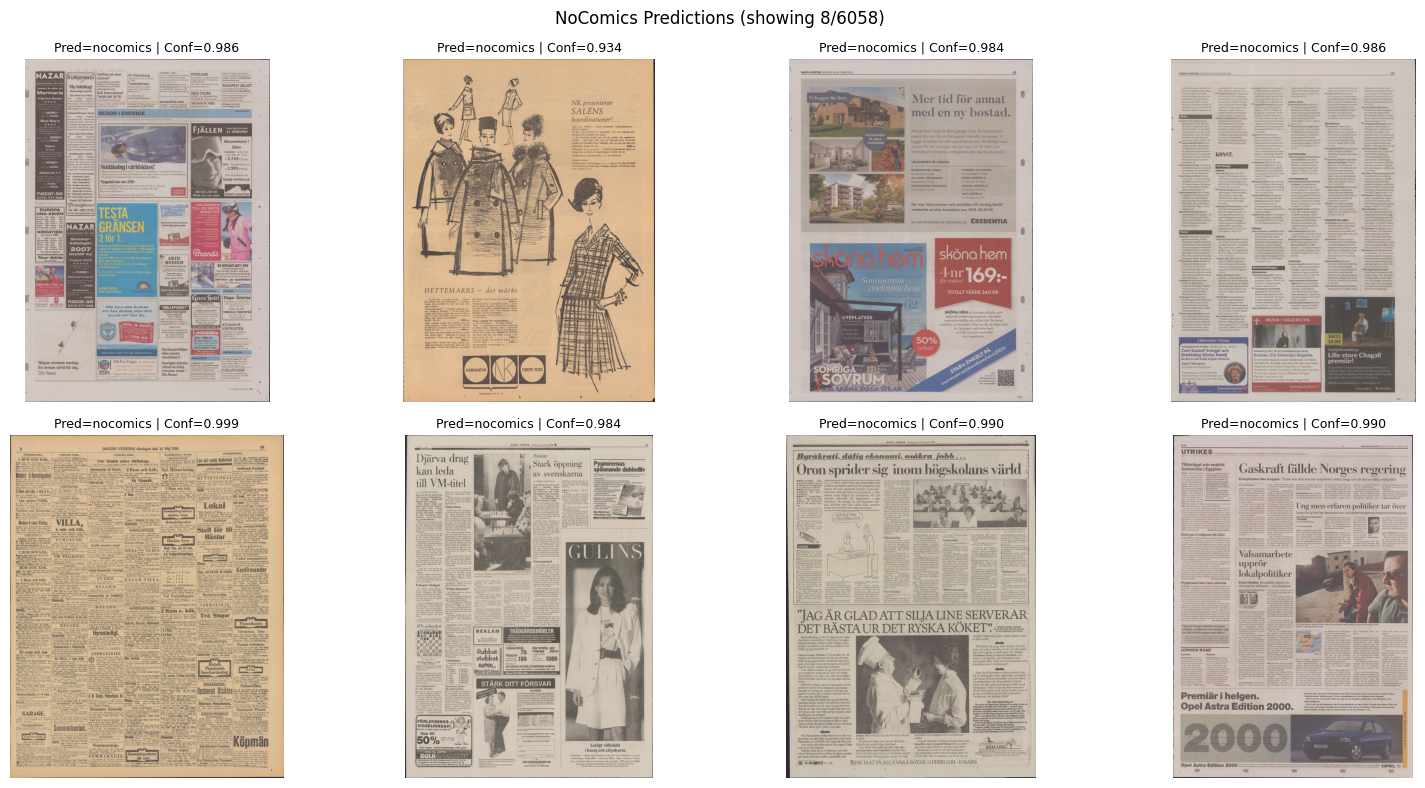

In [8]:
detail_path = infer_output / "predictions_detailed.json"
rows = json.loads(detail_path.read_text(encoding="utf-8"))["rows"]

comics_rows = [r for r in rows if r["pred_name"] == "comics"]
nocomics_rows = [r for r in rows if r["pred_name"] == "nocomics"]

print(f"Total predictions: {len(rows)}")
print(f"Predicted comics: {len(comics_rows)}")
print(f"Predicted nocomics: {len(nocomics_rows)}")

def plot_group(group_rows, title, max_samples):
    if max_samples <= 0:
        print(f"Skip {title}: max_samples <= 0")
        return

    if len(group_rows) == 0:
        print(f"No samples in {title}")
        return

    sample_rows = random.sample(group_rows, min(max_samples, len(group_rows)))
    n = len(sample_rows)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes] 

    for ax in axes[n:]:
        ax.axis("off")

    for ax, row in zip(axes, sample_rows):
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"Pred={row['pred_name']} | Conf={row['confidence']:.3f}", fontsize=9)
        ax.axis("off")

    fig.suptitle(f"{title} (showing {n}/{len(group_rows)})", fontsize=12)
    plt.tight_layout()
    plt.show()

plot_group(comics_rows, "Comics Predictions", COMICS_VIZ_SAMPLES)
plot_group(nocomics_rows, "NoComics Predictions", NOCOMICS_VIZ_SAMPLES)